In [1]:
!pip install torchnet tensorboardX einops

from collections import OrderedDict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR, ConstantLR
from torchvision import transforms, models, datasets
from PIL import Image
from torchnet.meter import ClassErrorMeter
from tensorboardX import SummaryWriter
import torch.backends.cudnn as cudnn
import torch.utils.data as data
import torch.utils.model_zoo as model_zoo
import numpy as np
import torch.nn.functional as F
from torch.autograd import Variable
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
import copy
from einops.layers.torch import Rearrange, Reduce
from functools import partial
from torchvision.utils import make_grid


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
def count_images_per_class(dataloader):
    class_counts = {}
    class_to_idx = dataloader.dataset.class_to_idx
    idx_to_class = {v: k for (k, v) in class_to_idx.items()}
    for (class_name, idx) in class_to_idx.items():
        class_counts[idx] = 0
    for (_, labels) in tqdm(dataloader, desc='Counting images per class'):
        for label in labels:
            class_idx = label.item()
            class_counts[class_idx] += 1
    return class_counts

def calculate_class_weights(class_counts, weight_type='inverse'):
    counts = []
    class_indices = []
    for (class_idx, count) in class_counts.items():
        counts.append(count)
        class_indices.append(class_idx)
    sorted_indices = sorted(zip(class_indices, counts))
    class_indices = [pair[0] for pair in sorted_indices]
    counts = [pair[1] for pair in sorted_indices]
    counts = np.array(counts)
    if weight_type == 'inverse':
        weights = 1.0 / counts
    elif weight_type == 'sqrt_inverse':
        weights = 1.0 / np.sqrt(counts)
    else:
        raise ValueError("Invalid weight type. Choose 'inverse' or 'sqrt_inverse'.")
    weights = weights / np.sum(weights) * len(class_counts)
    class_weights = torch.tensor(weights, dtype=torch.float)
    return class_weights

class Trainer:

    def __init__(self, model, dataloaders, dataset_sizes, criterion, optimizer, scheduler=None, device=None, num_epochs=25, save_path=None):
        super().__init__()
        self.dataloaders = dataloaders
        self.dataset_sizes = dataset_sizes
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.num_epochs = num_epochs
        self.save_path = save_path
        self.best_model = copy.deepcopy(model.state_dict())
        self.best_acc = 0.0
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.model = model.to(self.device)

    def train(self):
        since = time.time()
        for epoch in range(self.num_epochs):
            print(f'Epoch {epoch + 1}/{self.num_epochs}')
            print('-' * 10)
            epoch_start = time.time()
            for phase in ['train', 'test']:
                if phase == 'train':
                    self.model.train()
                else:
                    self.model.eval()
                running_loss = 0.0
                running_corrects = 0
                dataloader = self.dataloaders[phase]
                progress_bar = tqdm(dataloader, desc=f'{phase} epoch {epoch + 1}/{self.num_epochs}', unit='batch')
                seen_samples = 0
                for (inputs, labels) in progress_bar:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)
                    self.optimizer.zero_grad()
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = self.model(inputs)
                        if isinstance(outputs, tuple) and len(outputs) == 2:
                            (main_output, aux_output) = outputs
                            main_loss = self.criterion(main_output, labels)
                            aux_loss = self.criterion(aux_output, labels)
                            loss = main_loss + 0.4 * aux_loss
                            (_, preds) = torch.max(main_output, 1)
                        else:
                            loss = self.criterion(outputs, labels)
                            (_, preds) = torch.max(outputs, 1)
                        if phase == 'train':
                            loss.backward()
                            self.optimizer.step()
                        running_loss += loss.item() * inputs.size(0)
                        running_corrects += torch.sum(preds == labels.data)
                        seen_samples += inputs.size(0)
                        current_loss = running_loss / seen_samples
                        progress_bar.set_postfix(loss=f'{current_loss:.4f}')
                if phase == 'train' and self.scheduler is not None:
                    self.scheduler.step()
                epoch_loss = running_loss / self.dataset_sizes[phase]
                epoch_acc = running_corrects.double() / self.dataset_sizes[phase]
                if phase == 'train':
                    self.history['train_loss'].append(epoch_loss)
                    self.history['train_acc'].append(epoch_acc.item())
                else:
                    self.history['val_loss'].append(epoch_loss)
                    self.history['val_acc'].append(epoch_acc.item())
                if phase == 'test':
                    if epoch_acc > self.best_acc:
                        self.best_acc = epoch_acc
                        self.best_model = copy.deepcopy(self.model.state_dict())
                    if epoch_loss < self.best_val_loss:
                        self.best_val_loss = epoch_loss
                        if self.save_path:
                            torch.save(self.model.state_dict(), self.save_path)
                            print(f'Model saved to {self.save_path}')
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            epoch_end = time.time()
            print(f'Epoch {epoch + 1} completed in {epoch_end - epoch_start:.0f} seconds')
        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best test Acc: {self.best_acc:.4f}')
        print(f'Best test Loss: {self.best_val_loss:.4f}')
        self.model.load_state_dict(self.best_model)
        return (self.model, self.history)

    def plot_history(self):
        plt.style.use('seaborn-v0_8-whitegrid')
        (fig, (ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))
        epochs = range(1, len(self.history['train_loss']) + 1)
        ax1.plot(epochs, self.history['train_loss'], 'o-', label='Train Loss', color='tab:blue', markersize=5, linewidth=2)
        ax1.plot(epochs, self.history['val_loss'], 'o--', label='Test Loss', color='tab:orange', markersize=5, linewidth=2)
        ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Epochs', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.legend(fontsize=12)
        ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax2.plot(epochs, self.history['train_acc'], 'o-', label='Train Acc', color='tab:green', markersize=5, linewidth=2)
        ax2.plot(epochs, self.history['val_acc'], 'o--', label='Test Acc', color='tab:red', markersize=5, linewidth=2)
        ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epochs', fontsize=12)
        ax2.set_ylabel('Accuracy', fontsize=12)
        ax2.legend(fontsize=12)
        ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

    def visualize_token_mixing_weights(self, patch_size, num_patches_side, block_idx=0):
        try:
            weights = self.model.mixer_blocks[block_idx].token_mlp[0].weight.detach().cpu()
        except AttributeError:
            print('Không thể truy cập weights. Kiểm tra lại cấu trúc model.')
            return
        print(f'Visualizing weights from Mixer Block {block_idx}, Token MLP Layer 1')
        print(f'Weight shape original: {weights.shape}')
        n_hidden = weights.shape[0]
        weights = weights.view(n_hidden, num_patches_side, num_patches_side)
        num_filters_to_show = min(64, n_hidden)
        weights_to_show = weights[:num_filters_to_show].unsqueeze(1)
        grid_img = make_grid(weights_to_show, nrow=8, normalize=True, scale_each=True, padding=1)
        plt.figure(figsize=(10, 10))
        plt.imshow(grid_img.permute(1, 2, 0), cmap='viridis')
        plt.title(f'Token-Mixing Weights (Block {block_idx})\nPatterns learned across spatial patches', fontsize=14)
        plt.axis('off')
        plt.show()


# --- MLP Mixer Model Classes ---

In [3]:
pair = lambda x: x if isinstance(x, tuple) else (x, x)

class PreNormResidual(nn.Module):

    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.fn(self.norm(x)) + x

def FeedForward(dim, dim_hidden, dropout=0.0, dense=nn.Linear):
    return nn.Sequential(dense(dim, dim_hidden), nn.GELU(), nn.Dropout(dropout), dense(dim_hidden, dim), nn.Dropout(dropout))

class MixerBlock(nn.Module):
    """Single MLP-Mixer block with token and channel mixing"""

    def __init__(self, num_patches, dim, tokens_mlp_dim, channels_mlp_dim, dropout=0.0):
        super().__init__()
        self.token_norm = nn.LayerNorm(dim)
        self.token_mlp = nn.Sequential(nn.Linear(num_patches, tokens_mlp_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(tokens_mlp_dim, num_patches), nn.Dropout(dropout))
        self.channel_mixing = PreNormResidual(dim, FeedForward(dim, channels_mlp_dim, dropout))

    def forward(self, x):
        y = self.token_norm(x)
        y = y.transpose(1, 2)
        y = self.token_mlp(y)
        y = y.transpose(1, 2)
        x = x + y
        x = self.channel_mixing(x)
        return x

class MLPMixer(nn.Module):

    def __init__(self, image_size, channels, patch_size, dim, depth, num_classes, token_expansion=2, channel_expansion=4, dropout=0.0):
        super().__init__()
        (image_h, image_w) = pair(image_size)
        assert image_h % patch_size == 0 and image_w % patch_size == 0, 'Image must be divisible by patch size'
        num_patches = image_h // patch_size * (image_w // patch_size)
        patch_dim = channels * patch_size * patch_size
        self.patch_embedding = nn.Sequential(Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2=patch_size), nn.Linear(patch_dim, dim))
        tokens_mlp_dim = int(num_patches * token_expansion)
        channels_mlp_dim = int(dim * channel_expansion)
        self.mixer_blocks = nn.ModuleList([MixerBlock(num_patches, dim, tokens_mlp_dim, channels_mlp_dim, dropout) for _ in range(depth)])
        self.layer_norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = self.patch_embedding(x)
        for block in self.mixer_blocks:
            x = block(x)
        x = self.layer_norm(x)
        x = x.mean(dim=1)
        x = self.head(x)
        return x


# --- Data Prep & Execution ---

In [4]:
train_transform = transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.201))])
test_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.201))])
train_dataset = datasets.CIFAR10(root='/kaggle/working/', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='/kaggle/working/', train=False, download=True, transform=test_transform)
dataloaders = {'train': data.DataLoader(train_dataset, batch_size=128, shuffle=True), 'test': data.DataLoader(test_dataset, batch_size=128, shuffle=False)}
dataset_sizes = {'train': len(train_dataset), 'test': len(test_dataset)}
class_names = train_dataset.classes
num_classes = len(class_names)
print('MNIST Data Prepared:')
print('Number of classes:', num_classes)
print('Train set size:', dataset_sizes['train'])
print('Test set size:', dataset_sizes['test'])


100%|██████████| 170M/170M [00:04<00:00, 36.6MB/s]


MNIST Data Prepared:
Number of classes: 10
Train set size: 50000
Test set size: 10000


In [5]:
image_size = 32
channels = 3
patch_size = 4
dim = 512
depth = 8
token_expansion = 0.5
channel_expansion = 4
model = MLPMixer(image_size=image_size, channels=channels, patch_size=patch_size, dim=dim, depth=depth, num_classes=10, token_expansion=token_expansion, channel_expansion=channel_expansion, dropout=0.1)
model = model.cuda()


In [6]:
num_epochs = 100
total_steps = num_epochs * len(dataloaders['train'])
MAX_LR = 0.003
optimizer = optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=0.05)
total_steps = num_epochs * len(dataloaders['train'])
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=MAX_LR, total_steps=total_steps, pct_start=0.3, anneal_strategy='cos', div_factor=25, final_div_factor=10000.0)
loss = nn.CrossEntropyLoss(label_smoothing=0.1)
device = torch.device('cuda')


Epoch 1/100
----------


train epoch 1/100: 100%|██████████| 391/391 [02:00<00:00,  3.24batch/s, loss=1.8919]


train Loss: 1.8919 Acc: 0.3336


test epoch 1/100: 100%|██████████| 79/79 [00:09<00:00,  8.75batch/s, loss=1.7014]


Model saved to /kaggle/working/best_model1.pth
test Loss: 1.7014 Acc: 0.4431
Epoch 1 completed in 130 seconds
Epoch 2/100
----------


...

test Loss: 1.0457 Acc: 0.8218
Epoch 99 completed in 137 seconds
Epoch 100/100
----------


train epoch 100/100: 100%|██████████| 391/391 [02:08<00:00,  3.05batch/s, loss=0.5234]


train Loss: 0.5234 Acc: 0.9912


test epoch 100/100: 100%|██████████| 79/79 [00:08<00:00,  9.04batch/s, loss=1.0774]


test Loss: 1.0774 Acc: 0.8121
Epoch 100 completed in 137 seconds
Training complete in 228m 53s
Best test Acc: 0.8237
Best test Loss: 0.9572

=== Plotting Performance Curves ===


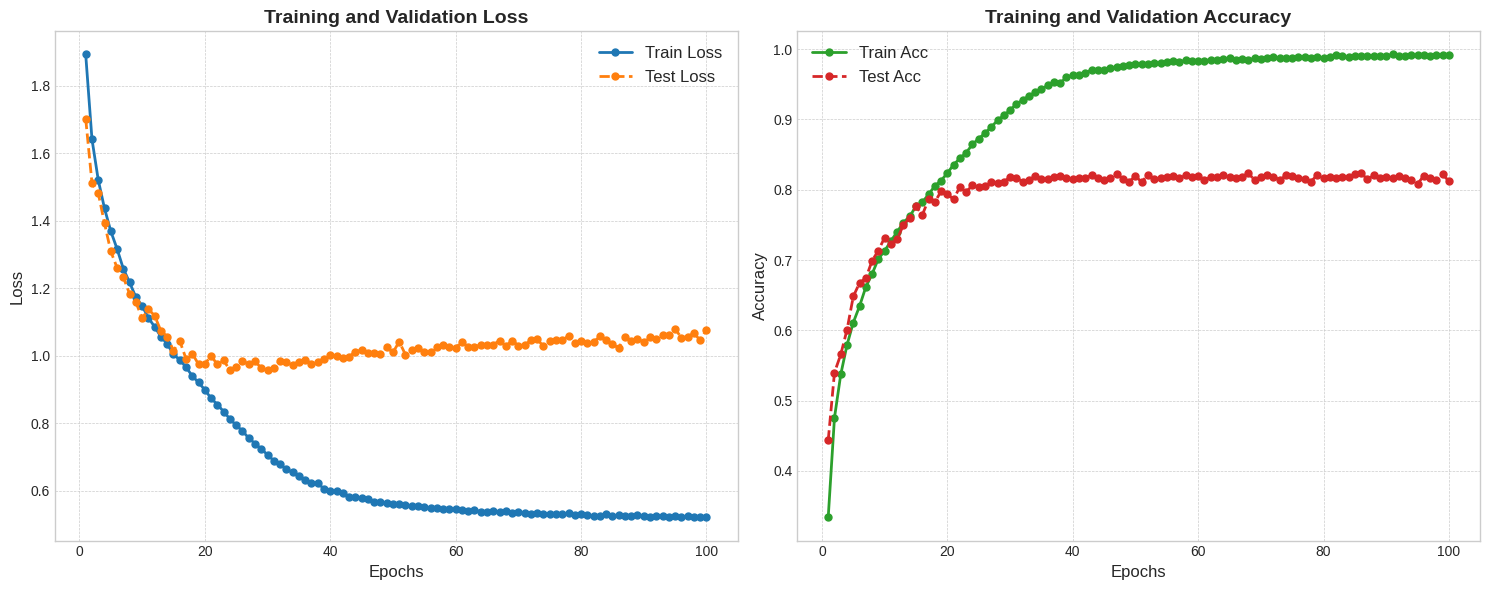


=== Visualizing Learned Weights ===
Visualizing weights from Mixer Block 0, Token MLP Layer 1
Weight shape original: torch.Size([32, 64])


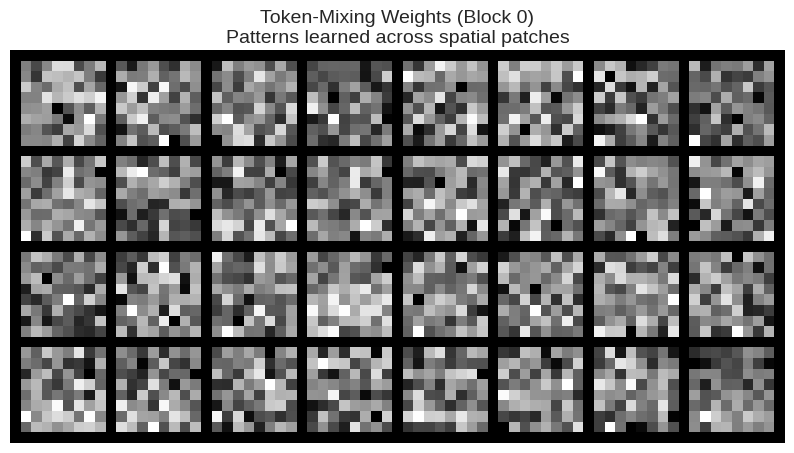

In [7]:
trainer = Trainer(model, dataloaders=dataloaders, dataset_sizes=dataset_sizes, criterion=loss, optimizer=optimizer, scheduler=scheduler, device=device, num_epochs=num_epochs, save_path='/kaggle/working/best_model1.pth')
trainer.train()
print('\n=== Plotting Performance Curves ===')
trainer.plot_history()
print('\n=== Visualizing Learned Weights ===')
trainer.visualize_token_mixing_weights(patch_size=patch_size, num_patches_side=image_size // patch_size, block_idx=0)
